# Constrained sampling on the ball with $J_s(x)=s\,[x]_\times$

The skew field is the one specified:

$$J_s(x)=\begin{pmatrix}0&-s x_3& s x_2\\ s x_3&0&-s x_1\\ -s x_2& s x_1&0\end{pmatrix},
\qquad\text{equivalently}\qquad J_s(x)\,w=s\,(x\times w),$$

on $K=\{x\in\mathbb R^3:\lVert x\rVert_2\le R\}$ with $R=0.75$, $\pi\propto e^{-U}\mathbf 1_K$, comparing
$J=0$ against $s=4,8$ on two targets, over 5000 iterations. At this radius both targets **fill** $K$ — the truncation is
severe enough that mass reaches the wall rather than sitting in a core with a gap around it, which is
checked quantitatively below.

## What this field gives you for free

Three properties, all verified numerically below rather than asserted:

1. **Antisymmetric** by inspection, exactly.
2. **Tangential at the wall**: $J_s(x)\nu(x)=s\,(x\times x)/\lVert x\rVert=0$ *identically*, not just to
   leading order. This is the condition a projected scheme needs — the skew drift must add no normal
   component at $\partial K$, or the projection absorbs flux and the stationary law is wrong by an amount
   no stepsize refinement removes.
3. **Divergence-free, exactly.** Writing $(J_s)_{ik}=s\,\varepsilon_{ijk}x_j$ gives
   $\partial_k (J_s)_{ik}=s\,\varepsilon_{ijk}\delta_{jk}=0$.

Property 3 is the one that changes the code. The general state-dependent anchored dynamics carries a
correction term,

$$dX=e^{\Delta}\bigl[-(I+J(X))\nabla U_0+\nabla\!\cdot J(X)\bigr]dt+\sqrt2\,e^{\Delta/2}dW,$$

and a field built to aim its rotation plane at a fixed subspace does **not** kill it — for the plane-aimed
family $J(x)=\tfrac{s}{R^2}(\lVert x\rVert^2A+(Ax)x^\top-x(Ax)^\top)$ one has
$\nabla\!\cdot J=-\tfrac{s}{R^2}(d-2)Ax\ne0$, so the correction has to be computed and carried at every
step. For $J_s=s[x]_\times$ it vanishes identically, so the implemented update is just

$$x\ \leftarrow\ \Pi_K\Bigl(x-\eta\,e^{\Delta}\bigl(I+J_s(x)\bigr)\nabla U_0+\sqrt{2\eta}\,e^{\Delta/2}\xi\Bigr),$$

with no extra gradient and nothing to get wrong.

## What it costs you

The rotation plane at $x$ is $x^\perp$ — fixed by position, not a free parameter. There is no way to aim
this field at the target's slow directions; the only knob is $s$. And since
$\lVert J_s(x)\rVert_2=s\lVert x\rVert$, the field **vanishes at the origin** and is strongest at the wall.
Both facts are measured below, and they are why $s$ eventually stops buying speed and starts costing
accuracy.

In [1]:
%matplotlib inline
import math, os, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib.patches import Circle
from scipy.stats import ks_2samp, wasserstein_distance

torch.set_default_dtype(torch.float64)
torch.set_num_threads(4)
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
# -----------------------------
# Settings
# -----------------------------
d        = 3
R        = 0.75         # K = {||x||_2 <= R}
N        = 5000         # walkers per replica
REPLICAS = 8            # independent replicas, run as one batched ensemble
MAXIT    = 5000         # well past the point where J = 0 settles at this radius
eta      = 5e-4
delta    = 0.1          # anchor smoothing
x_start  = 0.5
SEED     = 106
TRACK    = 25
S_LIST   = [4.0, 8.0]
S_TOP    = 8.0          # strongest field kept; used for the stepsize study

SCALES, RHO = [0.5, 1.0, 2.0], 0.6
def make_L(dim, scales, rho):
    Dm = np.diag(scales)
    Cm = np.full((dim, dim), rho); np.fill_diagonal(Cm, 1.0)
    return np.linalg.cholesky(Dm @ Cm @ Dm)

L3   = make_L(d, SCALES, RHO)
SIG  = L3 @ L3.T
Minv = torch.tensor(np.linalg.inv(L3))
EVAL, EVEC = np.linalg.eigh(SIG)
print("Sigma =\n", np.round(SIG, 3))
print("eigenvalues", np.round(EVAL, 3), "  condition number {:.1f}".format(EVAL[-1] / EVAL[0]))

Sigma =
 [[0.25 0.3  0.6 ]
 [0.3  1.   1.2 ]
 [0.6  1.2  4.  ]]
eigenvalues [0.131 0.595 4.525]   condition number 34.6


## The field, and the three conditions it has to meet

`Js_matrix` builds the specified matrix literally, entry by entry; `Js` is the matrix-free form
$s\,(x\times w)$ used in the sampler. The first check below is that they agree, so nothing is lost in the
fast path.

In [3]:
def Js_matrix(s, x):
    # the specified matrix, assembled entry by entry:
    #   [[0, -s x3,  s x2], [s x3, 0, -s x1], [-s x2, s x1, 0]]
    z = torch.zeros(len(x))
    return torch.stack([
        torch.stack([        z, -s * x[:, 2],  s * x[:, 1]], 1),
        torch.stack([ s * x[:, 2],         z, -s * x[:, 0]], 1),
        torch.stack([-s * x[:, 1],  s * x[:, 0],         z], 1)], 1)


@torch.no_grad()
def Js(s, x, g):
    # J_s(x) g = s (x cross g).  s = 0 gives the reversible scheme.
    return torch.zeros_like(g) if s == 0.0 else s * torch.cross(x, g, dim=1)


def autograd_div(s, x):
    # (div J)_i = sum_j d_j J_ij, by autograd, using no closed form
    n = x.shape[0]
    x = x.detach().clone().requires_grad_(True)
    out = torch.zeros(n, d)
    eye = torch.eye(d)
    for j in range(d):
        col = s * torch.cross(x, eye[j].expand(n, d), dim=1)
        for i in range(d):
            gi = torch.autograd.grad(col[:, i].sum(), x, retain_graph=True, allow_unused=True)[0]
            if gi is not None:
                out[:, i] += gi[:, j]
    return out.detach()


gen = torch.Generator().manual_seed(0)
xs = torch.randn(400, d, generator=gen)
gs = torch.randn(400, d, generator=gen)
wall = R * xs / xs.norm(dim=1, keepdim=True)
nu = wall / R

rows = []
for s in S_LIST:
    M = Js_matrix(s, xs)
    rows.append({
        "s": s,
        "matrix form vs s(x x g)": "{:.1e}".format(float(
            (torch.einsum("nij,nj->ni", M, gs) - Js(s, xs, gs)).abs().max())),
        "max |J + J^T|": "{:.1e}".format(float((M + M.transpose(1, 2)).abs().max())),
        "max |div J| (autograd)": "{:.1e}".format(float(autograd_div(s, xs[:40]).abs().max())),
        "max ||J nu|| on dK": "{:.1e}".format(float(Js(s, wall, nu).norm(dim=1).max())),
        "||J||_2 vs s||x||": "{:.1e}".format(float(
            (torch.linalg.matrix_norm(M, ord=2) - s * xs.norm(dim=1)).abs().max()))})
print("Antisymmetric, tangential at the wall, and divergence-free -- all exactly, at every")
print("strength used below.  The divergence column is what lets the correction term be dropped.\n")
pd.DataFrame(rows).set_index("s")

Antisymmetric, tangential at the wall, and divergence-free -- all exactly, at every
strength used below.  The divergence column is what lets the correction term be dropped.



,matrix form vs s(x x g),max |J + J^T|,max |div J| (autograd),max ||J nu|| on dK,||J||_2 vs s||x||
s,,,,,
4.0,3.6e-15,0.0e+00,0.0e+00,2.8e-16,5.3e-15
8.0,7.1e-15,0.0e+00,0.0e+00,5.6e-16,1.1e-14


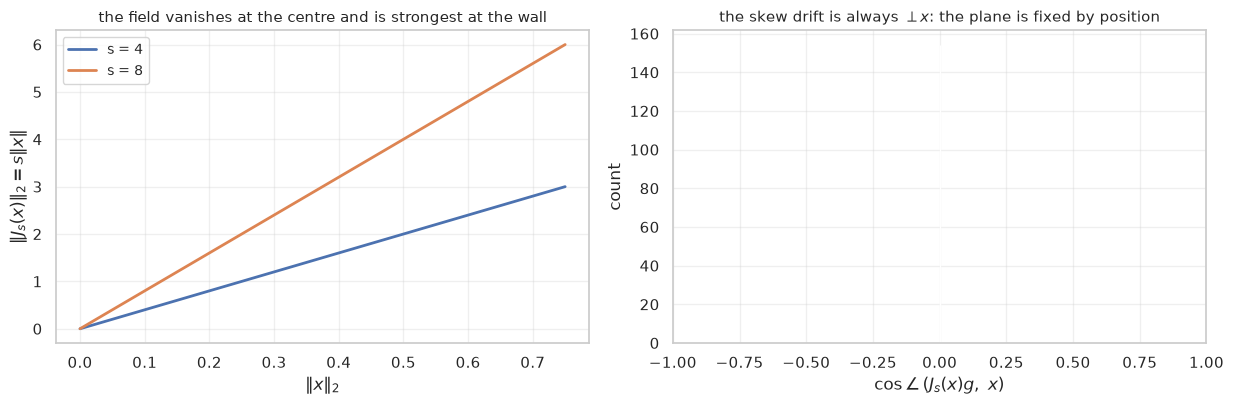

max |cos| = 1.2e-16   -> J_s(x)g is orthogonal to x for every x, so the rotation plane
is x-perp everywhere and cannot be aimed.  The only free parameter is s.


In [4]:
# the geometry the field cannot change: its rotation plane is x-perp, and its strength grows with ||x||
rr = np.linspace(0, R, 200)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for s in S_LIST:
    axes[0].plot(rr, s * rr, linewidth=2, label="s = {:g}".format(s))
axes[0].set_xlabel(r"$\|x\|_2$", fontsize=12)
axes[0].set_ylabel(r"$\|J_s(x)\|_2 = s\|x\|$", fontsize=12)
axes[0].set_title("the field vanishes at the centre and is strongest at the wall", fontsize=11)
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=10)

cos = (Js(8.0, xs, gs) * xs).sum(1) / (Js(8.0, xs, gs).norm(dim=1) * xs.norm(dim=1))
axes[1].hist(cos.numpy(), bins=40, color="#4C72B0")
axes[1].set_xlabel(r"$\cos\angle\,(J_s(x)g,\ x)$", fontsize=12)
axes[1].set_ylabel("count", fontsize=12)
axes[1].set_xlim(-1, 1)
axes[1].set_title(r"the skew drift is always $\perp x$: the plane is fixed by position", fontsize=11)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/cross_field_geometry.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("max |cos| = {:.1e}   -> J_s(x)g is orthogonal to x for every x, so the rotation plane".format(
    float(cos.abs().max())))
print("is x-perp everywhere and cannot be aimed.  The only free parameter is s.")

In [5]:
# -----------------------------
# Targets, exact reference samples by rejection, and the sampler
# -----------------------------
def build_target(kind):
    if kind == "ell":
        @torch.no_grad()
        def U(x):  return torch.norm(x @ Minv.T, dim=1)
        @torch.no_grad()
        def U0(x): return torch.sqrt(torch.sum((x @ Minv.T) ** 2, dim=1) + delta ** 2)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(torch.sum(y ** 2, dim=1, keepdim=True) + delta ** 2)) @ Minv
    else:
        @torch.no_grad()
        def U(x):  return torch.sum(torch.abs(x @ Minv.T), dim=1)
        @torch.no_grad()
        def U0(x): return torch.sum(torch.sqrt((x @ Minv.T) ** 2 + delta ** 2), dim=1)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(y ** 2 + delta ** 2)) @ Minv
    return U, U0, gU0


def sample_target(kind, n, rng):
    # draw from the unconstrained target, keep what lands in K -- exact
    out = []
    while len(out) < n:
        if kind == "ell":
            r = rng.gamma(d, 1.0, n)
            u = rng.normal(size=(n, d)); u /= np.linalg.norm(u, axis=1, keepdims=True)
            y = r[:, None] * u
        else:
            y = rng.laplace(0.0, 1.0, size=(n, d))
        z = y @ L3.T
        out.extend(z[np.linalg.norm(z, axis=1) <= R].tolist())
    return np.array(out[:n])


@torch.no_grad()
def proj_ball(x):
    nrm = torch.norm(x, dim=1, keepdim=True)
    return x * torch.clamp(R / nrm, max=1.0)


def on_boundary(X):
    return float(np.mean(np.linalg.norm(X, axis=1) > 0.999 * R))


def w1_floor(ref, kind, rng, reps=4):
    return float(np.mean([[wasserstein_distance(ref[:, i], sample_target(kind, len(ref), rng)[:, i])
                           for i in range(d)] for _ in range(reps)]))


@torch.no_grad()
def run_replicas(kind_target, s, ref, S=REPLICAS, n_steps=MAXIT, seed=SEED, eta=eta, track=TRACK):
    # Projected anchored Langevin with the J_s drift.
    # div J_s = 0 exactly, so there is NO correction term in this update -- contrast a
    # plane-aimed field, which needs one computed and carried at every step.
    U, U0, gU0 = build_target(kind_target)
    torch.manual_seed(seed)
    x = proj_ball(torch.full((S * N, d), x_start))
    it, W, Wc = [], [], []
    for k in range(n_steps):
        Delta = U(x) - U0(x)
        g = gU0(x) * torch.exp(Delta).unsqueeze(1)
        x = proj_ball(x - eta * (g + Js(s, x, g))
                      + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x))
        if (k + 1) % track == 0:
            xn = x.numpy().reshape(S, N, d)
            per = np.array([[wasserstein_distance(ref[:, i], xn[r, :, i]) for i in range(d)]
                            for r in range(S)])
            it.append(k + 1)
            W.append(per.mean(axis=1))
            Wc.append(per.mean(axis=0))
    return np.array(it), np.array(W).T, np.array(Wc), x.numpy().reshape(S, N, d)


def tau_one(it, w, thr):
    bad = np.where(w > thr)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return float(it[j]) if j < len(it) else np.nan


def boot(v, B=4000, seed=0):
    v = np.asarray(v, float)
    if not np.any(np.isfinite(v)):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = [np.nanmean(x) for x in (v[rng.integers(0, len(v), len(v))] for _ in range(B))
             if np.any(np.isfinite(x))]
    return np.nanmean(v), float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))


def boot_speedup(base, cur, B=4000, seed=1):
    base, cur = np.asarray(base, float), np.asarray(cur, float)
    if not (np.any(np.isfinite(base)) and np.any(np.isfinite(cur))):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(B):
        a, b = base[rng.integers(0, len(base), len(base))], cur[rng.integers(0, len(cur), len(cur))]
        if np.any(np.isfinite(a)) and np.any(np.isfinite(b)):
            draws.append(np.nanmean(a) / np.nanmean(b))
    return (np.nanmean(base) / np.nanmean(cur),
            float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)))


def fmt_tau(t):
    return "never" if not np.isfinite(t[0]) else "{:.0f} [{:.0f}, {:.0f}]".format(*t)


def fmt_speed(sp):
    return "never reaches it" if not np.isfinite(sp[0]) else "{:.2f}x [{:.2f}, {:.2f}]".format(*sp)

## Runs

$\tau$ is the iteration at which the mean $W_1$ reaches twice the sampling floor and stays there — the
floor being $W_1$ between two independent exact draws, which no sampler can beat. Bands and intervals are
over 8 independent replicas.

In [6]:
TARGETS = {"ell": "Target A: elliptical Laplace on $K$",
           "l1":  "Target B: correlated $\\ell_1$ Laplace on $K$"}
GRID = [(0.0, "J = 0")] + [(s, "$J_s$, s={:g}".format(s)) for s in S_LIST]

# tau is read at several multiples of the floor.  A threshold close to a scheme's own
# stationary error turns tau into a noise statistic (the curve keeps re-crossing it), so
# each entry is reported only where the scheme actually settles below the threshold.
MULT = (2.0, 3.0, 5.0)

rng = np.random.default_rng(SEED)
refs, floors, RES = {}, {}, {}
for kind in TARGETS:
    refs[kind] = sample_target(kind, N, rng)
    floors[kind] = w1_floor(refs[kind], kind, rng)
    RES[kind] = {}
    print("\n### {}   floor {:.4f}   target mass on dK {:.4f}".format(
        kind, floors[kind], on_boundary(refs[kind])), flush=True)
    for s, lab in GRID:
        t0 = time.time()
        it, W, Wc, X = run_replicas(kind, s, refs[kind])
        RES[kind][lab] = {"it": it, "W": W, "Wc": Wc, "X": X, "s": s,
                          "taus": {m: np.array([tau_one(it, w, m * floors[kind]) for w in W])
                                   for m in MULT},
                          "stat": W[:, -10:].mean(axis=1),
                          "bd": on_boundary(X.reshape(-1, d))}
        print("   {:<20} {:5.0f}s".format(lab.replace("$", ""), time.time() - t0), flush=True)

MAIN = [lab for _, lab in GRID]
COL = {"J = 0": "#C44E52", "$J_s$, s=4": "#DD8452", "$J_s$, s=8": "#55A868"}
TOP = "$J_s$, s={:g}".format(S_TOP)


### ell   floor 0.0092   target mass on dK 0.0030


   J = 0                   32s


   J_s, s=4                36s


   J_s, s=8                35s



### l1   floor 0.0079   target mass on dK 0.0024


   J = 0                   30s


   J_s, s=4                32s


   J_s, s=8                31s


### Does the target actually fill $K$?

A constrained experiment is only about the constraint if the target reaches the wall. The check: the
radial quantiles of $\lVert x
Vert/R$, and the mass beyond $0.75R$ against the value a **uniform** ball
would give, $1-0.75^3=0.578$. A target sitting in a core with a gap around it would score far below that;
one that fills $K$ scores close to it.

In [7]:
rows = []
for kind in TARGETS:
    r = np.linalg.norm(refs[kind], axis=1) / R
    sd = refs[kind].std(0)
    rows.append({"target": kind,
                 "median ||x||/R": round(float(np.median(r)), 3),
                 "q90": round(float(np.quantile(r, 0.90)), 3),
                 "q99": round(float(np.quantile(r, 0.99)), 3),
                 "mass beyond 0.75R": round(float(np.mean(r > 0.75)), 3),
                 "  (uniform ball)": round(1 - 0.75 ** 3, 3),
                 "coordinate sds": np.round(sd, 3),
                 "anisotropy": round(float(sd.max() / sd.min()), 2)})
display(pd.DataFrame(rows).set_index("target"))
print("Mass reaches the wall (q99 ~ 0.99R) and the outer-shell fraction is within ~25% of the")
print("uniform-ball value, so K is filled rather than partly occupied.")
print()
print("Note the anisotropy column: truncating at R = 0.75 leaves the constrained target much closer")
print("to isotropic than the unconstrained one.  Whatever acceleration J_s produces here therefore")
print("comes from the geometry of the constraint, not from stretched directions in the target.")

,median ||x||/R,q90,q99,mass beyond 0.75R,(uniform ball),coordinate sds,anisotropy
target,,,,,,,
ell,0.742,0.955,0.995,0.487,0.578,"[0.275, 0.325, 0.353]",1.28
l1,0.713,0.945,0.996,0.434,0.578,"[0.238, 0.326, 0.349]",1.46


Mass reaches the wall (q99 ~ 0.99R) and the outer-shell fraction is within ~25% of the
uniform-ball value, so K is filled rather than partly occupied.

Note the anisotropy column: truncating at R = 0.75 leaves the constrained target much closer
to isotropic than the unconstrained one.  Whatever acceleration J_s produces here therefore
comes from the geometry of the constraint, not from stretched directions in the target.


## Experiment 1 — $W_1$ to the constrained target

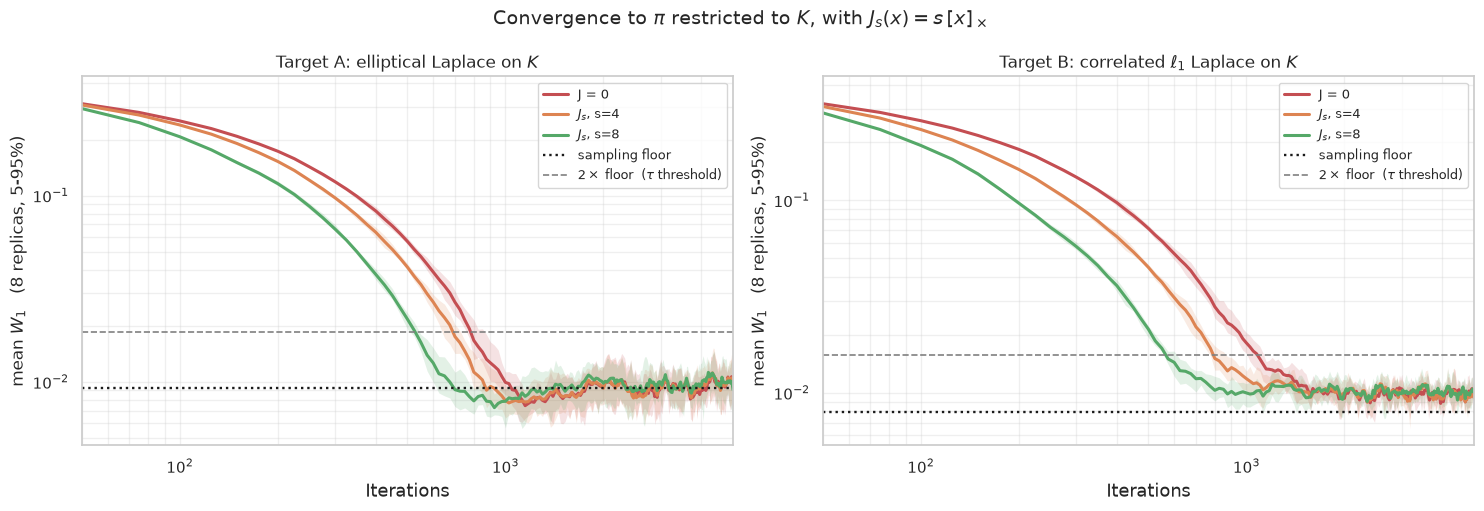

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, kind in zip(axes, TARGETS):
    for lab in MAIN:
        r = RES[kind][lab]
        ax.plot(r["it"], r["W"].mean(axis=0), linewidth=2.2, color=COL[lab], label=lab)
        ax.fill_between(r["it"], np.percentile(r["W"], 5, axis=0),
                        np.percentile(r["W"], 95, axis=0), color=COL[lab], alpha=0.16, linewidth=0)
    ax.axhline(floors[kind], color="k", linestyle=":", linewidth=1.7, label="sampling floor")
    ax.axhline(2 * floors[kind], color="0.5", linestyle="--", linewidth=1.2,
               label=r"$2\times$ floor  ($\tau$ threshold)")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(50, MAXIT)
    ax.set_xlabel("Iterations", fontsize=13)
    ax.set_ylabel(r"mean $W_1$   ({} replicas, 5-95%)".format(REPLICAS), fontsize=12)
    ax.set_title(TARGETS[kind], fontsize=12)
    ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=9)
fig.suptitle(r"Convergence to $\pi$ restricted to $K$, with $J_s(x)=s\,[x]_\times$", fontsize=14)
plt.tight_layout()
plt.savefig("figures/cross_w1.pdf", dpi=300, bbox_inches="tight")
plt.show()

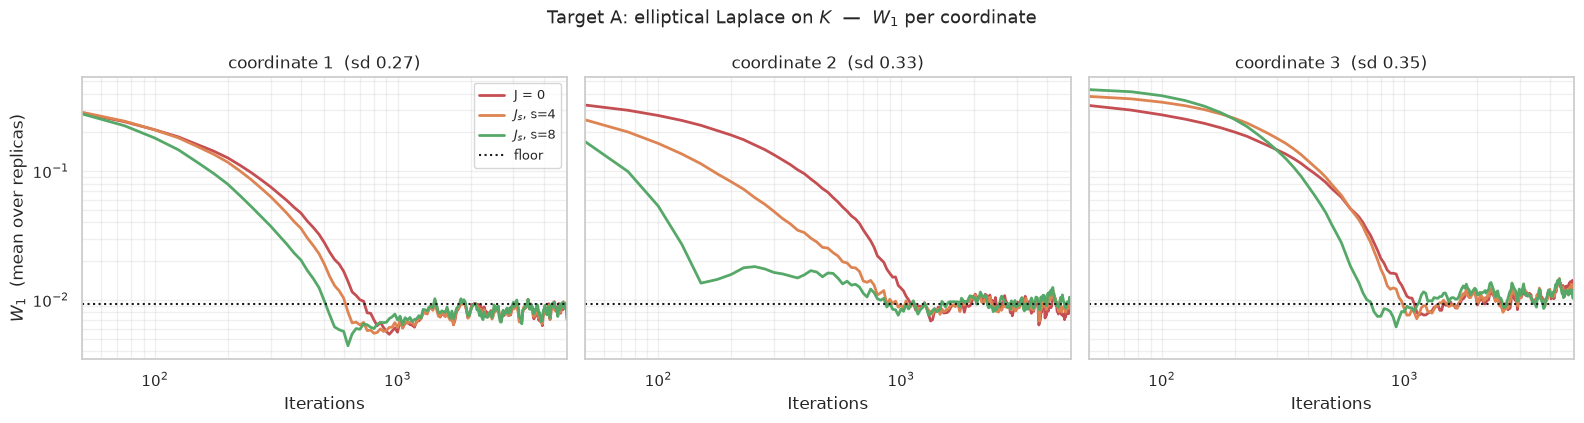

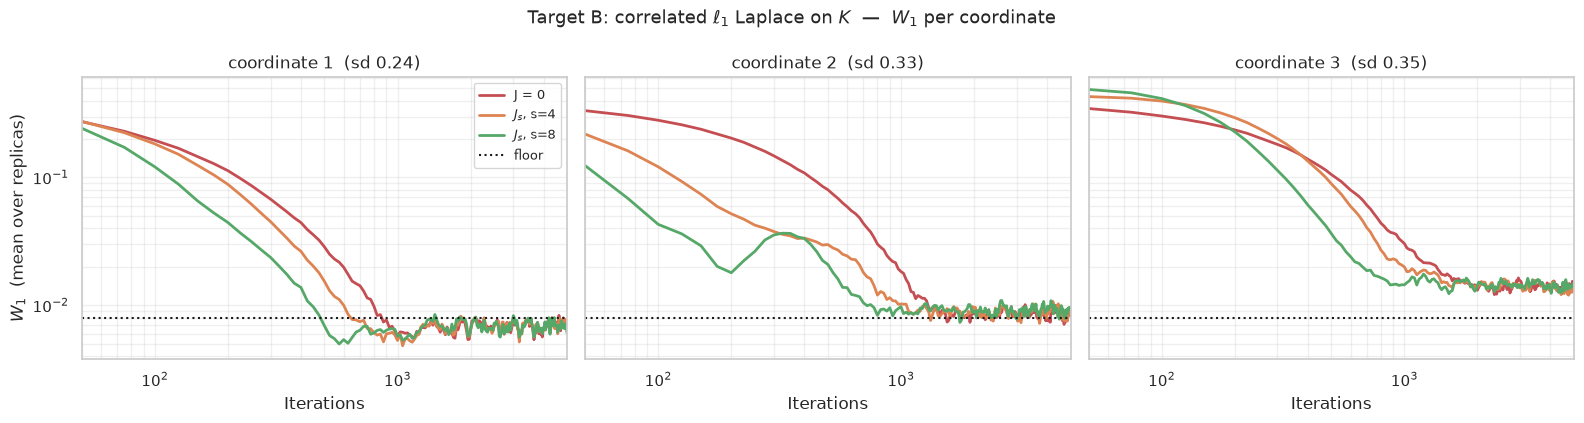

In [9]:
# per-coordinate: the three coordinates have very different length scales, so the mean hides
# which direction the rotation is actually helping
for kind in TARGETS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharey=True)
    for i, ax in enumerate(axes):
        for lab in MAIN:
            r = RES[kind][lab]
            ax.plot(r["it"], r["Wc"][:, i], linewidth=2, color=COL[lab], label=lab)
        ax.axhline(floors[kind], color="k", linestyle=":", linewidth=1.5, label="floor")
        ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(50, MAXIT)
        ax.set_xlabel("Iterations", fontsize=12)
        ax.set_title("coordinate {}  (sd {:.2f})".format(i + 1, refs[kind][:, i].std()), fontsize=12)
        ax.grid(alpha=0.3, which="both")
    axes[0].set_ylabel(r"$W_1$  (mean over replicas)", fontsize=12)
    axes[0].legend(fontsize=9)
    fig.suptitle(TARGETS[kind] + r"  —  $W_1$ per coordinate", fontsize=13)
    plt.tight_layout()
    plt.savefig("figures/cross_w1_percoord_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 2 — the targets, inside $K$

Top row: the 2-d marginal in dims 1 and 2 with $\partial K$ drawn, reference first. Bottom row: the radial
law of $\lVert x\rVert$, which is where the constraint actually bites — projection deposits an atom at
$\lVert x\rVert=R$ that the continuous target does not have.

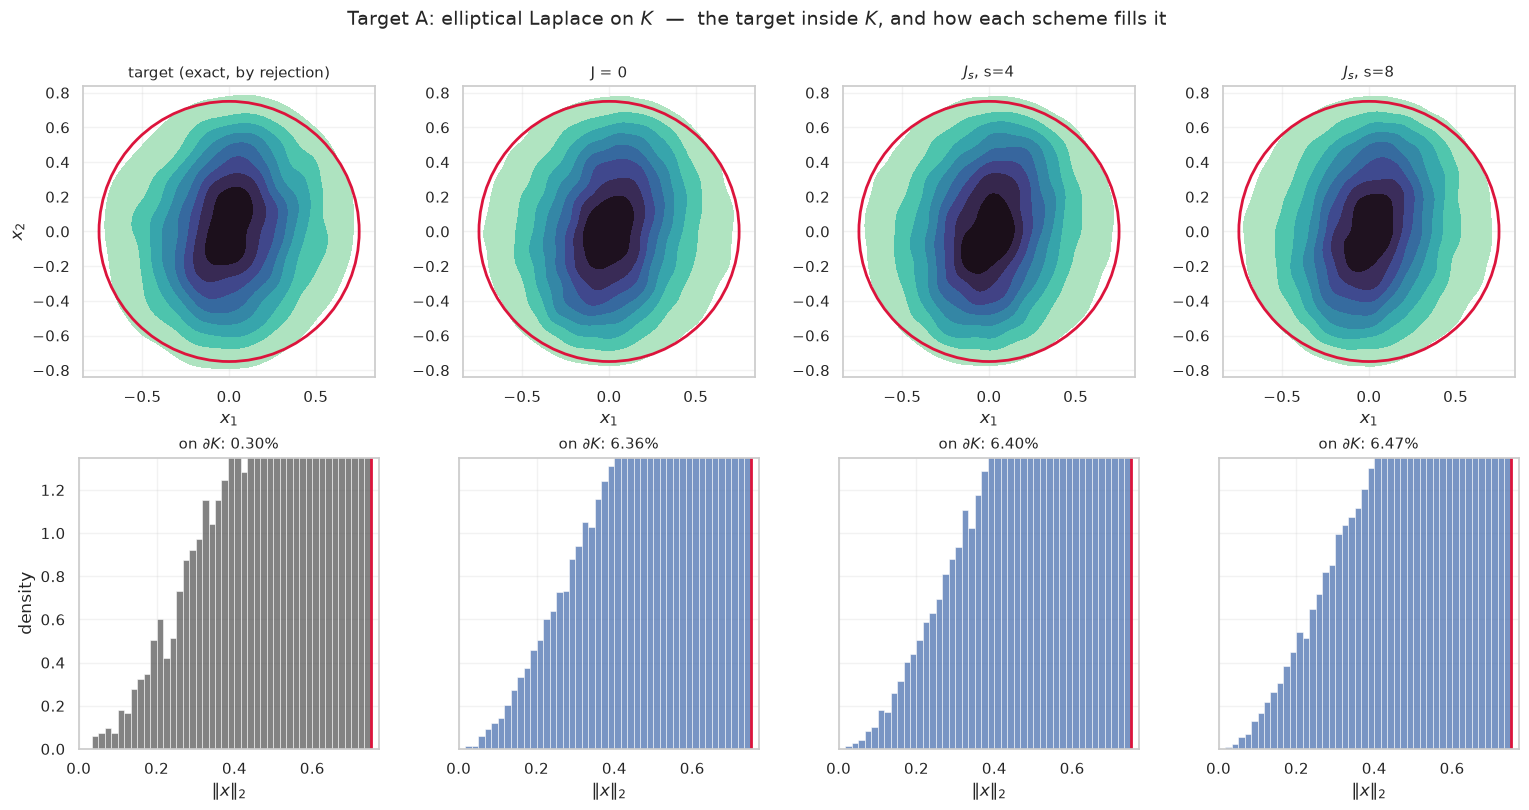

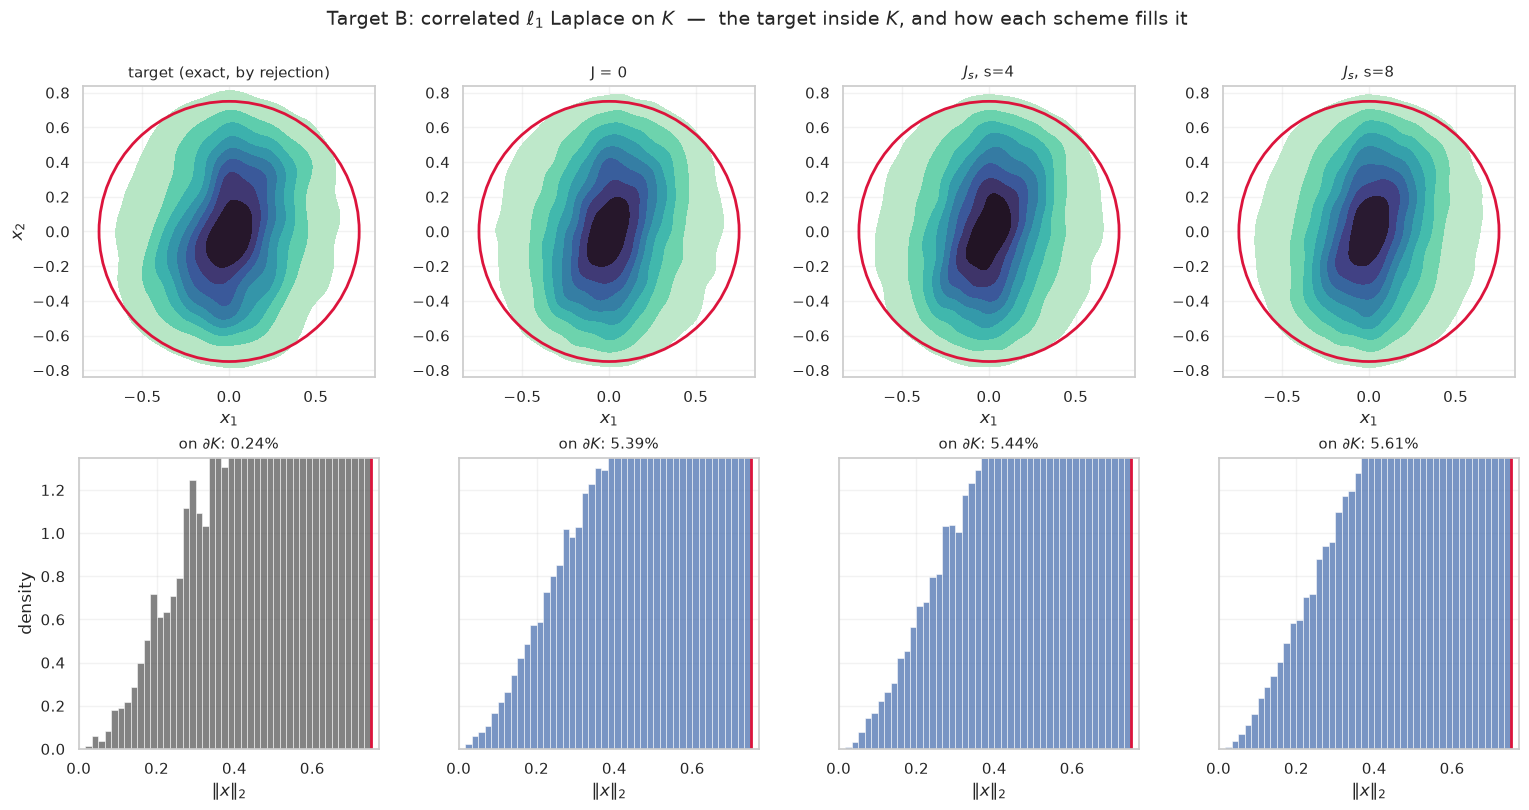

In [10]:
for kind in TARGETS:
    panels = [("target (exact, by rejection)", refs[kind])] + [
        (lab, RES[kind][lab]["X"].reshape(-1, d)) for lab in MAIN]
    fig, axes = plt.subplots(2, len(panels), figsize=(3.9 * len(panels), 8.0))
    for j, (name, X) in enumerate(panels):
        ax = axes[0, j]
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=9, ax=ax, thresh=0.02, cmap="mako_r")
        ax.add_patch(Circle((0, 0), R, edgecolor="crimson", facecolor="none", linewidth=2.0))
        ax.set_xlim(-1.12 * R, 1.12 * R); ax.set_ylim(-1.12 * R, 1.12 * R)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("$x_1$", fontsize=12)
        ax.set_aspect("equal", adjustable="box"); ax.grid(alpha=0.25)
        if j == 0:
            ax.set_ylabel("$x_2$", fontsize=12)
        ax = axes[1, j]
        r = np.linalg.norm(X, axis=1)
        sns.histplot(x=r, bins=np.linspace(0, R, 46), stat="density", ax=ax,
                     color="#4C72B0" if j else "0.35", edgecolor=None)
        ax.axvline(R, color="crimson", linewidth=2.0)
        ax.set_xlim(0, 1.03 * R); ax.set_ylim(0, 1.35)
        ax.set_xlabel(r"$\|x\|_2$", fontsize=12)
        ax.set_title("on $\\partial K$: {:.2%}".format(on_boundary(X)), fontsize=11)
        ax.grid(alpha=0.25)
        ax.set_ylabel("density" if j == 0 else "", fontsize=12)
        if j:
            ax.set_yticklabels([])
    fig.suptitle(TARGETS[kind] + r"  —  the target inside $K$, and how each scheme fills it",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("figures/cross_inK_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 3 — head to head

In [11]:
HEADROOM = 1.5     # threshold must clear the scheme's own stationary error by this factor

def tau_cell(r, kind, m, base=None):
    # tau at m x floor.  It is a rate only if the threshold sits well above the scheme's OWN
    # stationary error; otherwise the curve keeps re-crossing and tau measures noise.
    if m * floors[kind] < HEADROOM * r["stat"].mean():
        return "too close"
    t = boot(r["taus"][m])
    if not np.isfinite(t[0]):
        return "too close"
    if base is None:
        return "{:.0f} [{:.0f}, {:.0f}]".format(*t)
    return "{:.0f}  ({})".format(t[0], fmt_speed(boot_speedup(base, r["taus"][m])).split(" [")[0])

for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    rows = []
    for lab in MAIN:
        r = RES[kind][lab]
        ks = np.mean([max(ks_2samp(refs[kind][:, i], r["X"][j, :, i]).statistic for i in range(d))
                      for j in range(REPLICAS)])
        row = {"scheme": lab.replace("$", "")}
        for m in MULT:
            row["tau ({:g}x floor)".format(m)] = tau_cell(
                r, kind, m, None if r["s"] == 0 else base[m])
        row.update({"stationary W1": "{:.4f} [{:.4f}, {:.4f}]".format(*boot(r["stat"])),
                    "max KS": round(float(ks), 4),
                    "mass on dK": "{:.2%}".format(r["bd"])})
        rows.append(row)
    row = {"scheme": "target (truth)"}
    for m in MULT:
        row["tau ({:g}x floor)".format(m)] = "--"
    row.update({"stationary W1": "{:.4f}  (floor)".format(floors[kind]), "max KS": 0.0,
                "mass on dK": "{:.2%}".format(on_boundary(refs[kind]))})
    rows.append(row)
    print("\n### {}   (J = 0 columns are absolute; the rest are tau, with the speed-up in brackets)"
          .format(TARGETS[kind]))
    display(pd.DataFrame(rows).set_index("scheme"))


### Target A: elliptical Laplace on $K$   (J = 0 columns are absolute; the rest are tau, with the speed-up in brackets)


,tau (2x floor),tau (3x floor),tau (5x floor),stationary W1,max KS,mass on dK
scheme,,,,,,
J = 0,"803 [781, 834]","703 [684, 716]","572 [562, 581]","0.0101 [0.0091, 0.0111]",0.0235,6.36%
"J_s, s=4",700 (1.15x),609 (1.15x),488 (1.17x),"0.0101 [0.0091, 0.0111]",0.0235,6.40%
"J_s, s=8",534 (1.50x),472 (1.49x),375 (1.52x),"0.0099 [0.0088, 0.0109]",0.0228,6.47%
target (truth),--,--,--,0.0092 (floor),0.0000,0.30%



### Target B: correlated $\ell_1$ Laplace on $K$   (J = 0 columns are absolute; the rest are tau, with the speed-up in brackets)


,tau (2x floor),tau (3x floor),tau (5x floor),stationary W1,max KS,mass on dK
scheme,,,,,,
J = 0,"1109 [1066, 1153]","881 [847, 919]","709 [691, 728]","0.0101 [0.0096, 0.0106]",0.0257,5.39%
"J_s, s=4",812 (1.37x),694 (1.27x),544 (1.30x),"0.0097 [0.0093, 0.0102]",0.0251,5.44%
"J_s, s=8",591 (1.88x),491 (1.80x),388 (1.83x),"0.0101 [0.0095, 0.0105]",0.0263,5.61%
target (truth),--,--,--,0.0079 (floor),0.0000,0.24%


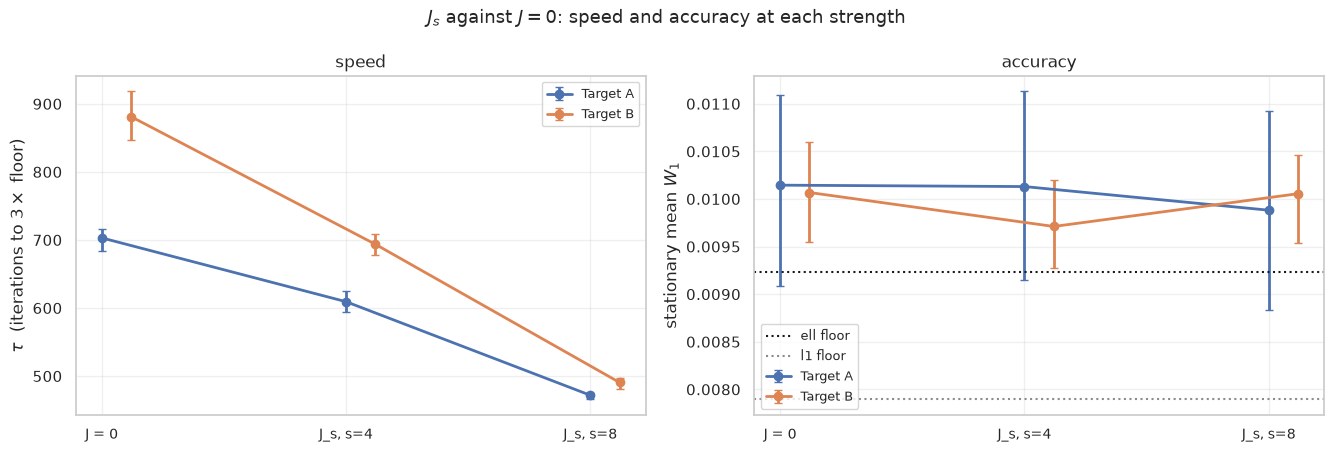

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
for col, kind in enumerate(TARGETS):
    tm = [boot(RES[kind][l]["taus"][3.0]) for l in MAIN]
    st = [boot(RES[kind][l]["stat"]) for l in MAIN]
    xs_ = np.arange(len(MAIN))
    axes[0].errorbar(xs_ + col * 0.12, [v[0] for v in tm],
                     yerr=[[v[0] - v[1] for v in tm], [v[2] - v[0] for v in tm]],
                     fmt="o-", capsize=3, linewidth=2, label=TARGETS[kind].split(":")[0])
    axes[1].errorbar(xs_ + col * 0.12, [v[0] for v in st],
                     yerr=[[v[0] - v[1] for v in st], [v[2] - v[0] for v in st]],
                     fmt="o-", capsize=3, linewidth=2, label=TARGETS[kind].split(":")[0])
    axes[1].axhline(floors[kind], linestyle=":", linewidth=1.5,
                    color=["k", "0.55"][col], label="{} floor".format(kind))
for ax, ylab, title in [(axes[0], r"$\tau$  (iterations to $3\times$ floor)", "speed"),
                        (axes[1], r"stationary mean $W_1$", "accuracy")]:
    ax.set_xticks(np.arange(len(MAIN)))
    ax.set_xticklabels([l.replace("$", "") for l in MAIN], fontsize=10)
    ax.set_ylabel(ylab, fontsize=12); ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.suptitle(r"$J_s$ against $J=0$: speed and accuracy at each strength", fontsize=13)
plt.tight_layout()
plt.savefig("figures/cross_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 4 — spending the speed-up on the boundary atom

At fixed $\eta$ the atom is flat across $s$, and it has to be: it is a **discretisation** artefact of the
projection, driven by the *normal* component of a step near the wall, and $J_s$ is exactly tangential — it
adds no normal drift at all. Nothing about a tangential field can remove it while $\eta$ is held fixed.

But it scales like $\sqrt\eta$, and the speed-up is real, so it can be spent. Refining $\eta$ by $c$
multiplies the iterations needed by roughly $c$ and the atom by roughly $1/\sqrt c$. The question is
whether there is a $c$ at which $J_s$ still converges in fewer iterations than $J=0$ does at the coarse
stepsize while leaving less mass on the wall.

In [13]:
REFINE = [2, 4]
RES_R = {}
for kind in TARGETS:
    RES_R[kind] = {}
    for c in REFINE:
        lab = "{}, $\\eta$/{}".format(TOP, c)
        t0 = time.time()
        it, W, Wc, X = run_replicas(kind, S_TOP, refs[kind],
                                    n_steps=MAXIT * c, eta=eta / c, track=TRACK * c)
        RES_R[kind][lab] = {"it": it, "W": W, "Wc": Wc, "X": X, "s": S_TOP, "c": c,
                            "taus": {m: np.array([tau_one(it, w, m * floors[kind]) for w in W])
                                     for m in MULT},
                            "stat": W[:, -10:].mean(axis=1),
                            "bd": on_boundary(X.reshape(-1, d))}
        print("   {:<24} {:5.0f}s".format(kind + "  eta/" + str(c), time.time() - t0), flush=True)

   ell  eta/2                  56s


   ell  eta/4                 105s


   l1  eta/2                   57s


   l1  eta/4                  108s


In [14]:
for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    rows = []
    entries = [("$J = 0$", RES[kind]["J = 0"], 1),
               (TOP, RES[kind][TOP], 1)]
    entries += [(k, v, v["c"]) for k, v in RES_R[kind].items()]
    for lab, r, c in entries:
        ok = (3.0 * floors[kind] >= HEADROOM * r["stat"].mean()
              and np.any(np.isfinite(r["taus"][3.0])))
        rows.append({"scheme": lab.replace("$", "").replace("\\eta", "eta"),
                     "eta": "{:.1e}".format(eta / c),
                     "tau (3x floor)": fmt_tau(boot(r["taus"][3.0])) if ok else "too close",
                     "vs J=0 iterations": "--" if lab == "$J = 0$" else (
                         "{:.2f}x".format(np.nanmean(base[3.0]) / np.nanmean(r["taus"][3.0]))
                         if ok else "--"),
                     "stationary W1": "{:.4f} [{:.4f}, {:.4f}]".format(*boot(r["stat"])),
                     "mass on dK": "{:.2%}".format(r["bd"]),
                     "atom / sqrt(eta)": round(r["bd"] / np.sqrt(eta / c), 3)})
    rows.append({"scheme": "target (truth)", "eta": "--", "tau (3x floor)": "--",
                 "vs J=0 iterations": "--",
                 "stationary W1": "{:.4f}  (floor)".format(floors[kind]),
                 "mass on dK": "{:.2%}".format(on_boundary(refs[kind])), "atom / sqrt(eta)": "--"})
    print("\n### {}".format(TARGETS[kind]))
    display(pd.DataFrame(rows).set_index("scheme"))


### Target A: elliptical Laplace on $K$


,eta,tau (3x floor),vs J=0 iterations,stationary W1,mass on dK,atom / sqrt(eta)
scheme,,,,,,
J = 0,5.0e-04,"703 [684, 716]",--,"0.0101 [0.0091, 0.0111]",6.36%,2.845
"J_s, s=8",5.0e-04,"472 [466, 475]",1.49x,"0.0099 [0.0088, 0.0109]",6.47%,2.895
"J_s, s=8, eta/2",2.5e-04,"919 [906, 938]",0.77x,"0.0077 [0.0069, 0.0088]",4.61%,2.916
"J_s, s=8, eta/4",1.3e-04,"1812 [1775, 1850]",0.39x,"0.0088 [0.0077, 0.0100]",3.54%,3.164
target (truth),--,--,--,0.0092 (floor),0.30%,--



### Target B: correlated $\ell_1$ Laplace on $K$


,eta,tau (3x floor),vs J=0 iterations,stationary W1,mass on dK,atom / sqrt(eta)
scheme,,,,,,
J = 0,5.0e-04,"881 [847, 919]",--,"0.0101 [0.0096, 0.0106]",5.39%,2.412
"J_s, s=8",5.0e-04,"491 [481, 497]",1.80x,"0.0101 [0.0095, 0.0105]",5.61%,2.51
"J_s, s=8, eta/2",2.5e-04,"975 [944, 1006]",0.90x,"0.0094 [0.0091, 0.0096]",3.97%,2.512
"J_s, s=8, eta/4",1.3e-04,"1900 [1850, 1950]",0.46x,"0.0090 [0.0087, 0.0093]",3.03%,2.71
target (truth),--,--,--,0.0079 (floor),0.24%,--


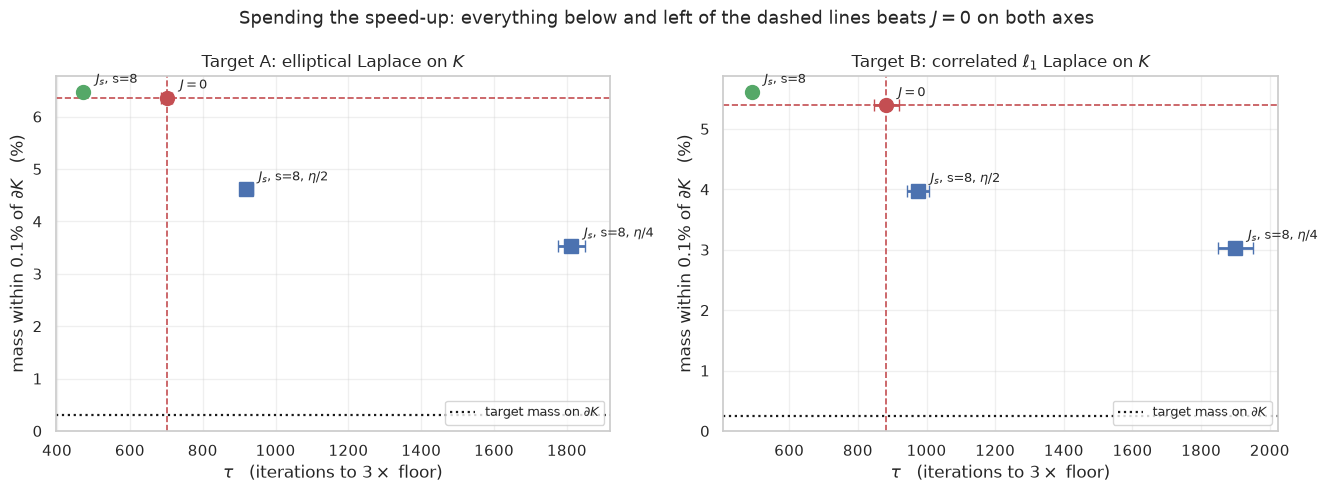

In [15]:
# the dominance picture: down and to the left beats J = 0 on both axes at once
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for ax, kind in zip(axes, TARGETS):
    pts = [("$J = 0$", RES[kind]["J = 0"], "#C44E52", "o"),
           (TOP, RES[kind][TOP], "#55A868", "o")]
    pts += [(k, v, "#4C72B0", "s") for k, v in RES_R[kind].items()]
    for lab, r, c, mk in pts:
        t = boot(r["taus"][3.0])
        if not np.isfinite(t[0]):
            continue
        ax.errorbar(t[0], r["bd"] * 100, xerr=[[t[0] - t[1]], [t[2] - t[0]]],
                    fmt=mk, color=c, markersize=10, capsize=4, linewidth=2)
        ax.annotate(lab, (t[0], r["bd"] * 100), textcoords="offset points",
                    xytext=(9, 6), fontsize=9)
    j0 = boot(RES[kind]["J = 0"]["taus"][3.0])
    ax.axvline(j0[0], color="#C44E52", linestyle="--", linewidth=1.2)
    ax.axhline(RES[kind]["J = 0"]["bd"] * 100, color="#C44E52", linestyle="--", linewidth=1.2)
    ax.axhline(on_boundary(refs[kind]) * 100, color="k", linestyle=":", linewidth=1.6,
               label="target mass on $\\partial K$")
    ax.set_xlabel(r"$\tau$   (iterations to $3\times$ floor)", fontsize=12)
    ax.set_ylabel(r"mass within 0.1% of $\partial K$   (%)", fontsize=12)
    ax.set_title(TARGETS[kind], fontsize=12)
    ax.set_ylim(0, None); ax.grid(alpha=0.3); ax.legend(fontsize=9, loc="lower right")
fig.suptitle("Spending the speed-up: everything below and left of the dashed lines beats "
             r"$J=0$ on both axes", fontsize=13)
plt.tight_layout()
plt.savefig("figures/cross_atom_tradeoff.pdf", dpi=300, bbox_inches="tight")
plt.show()

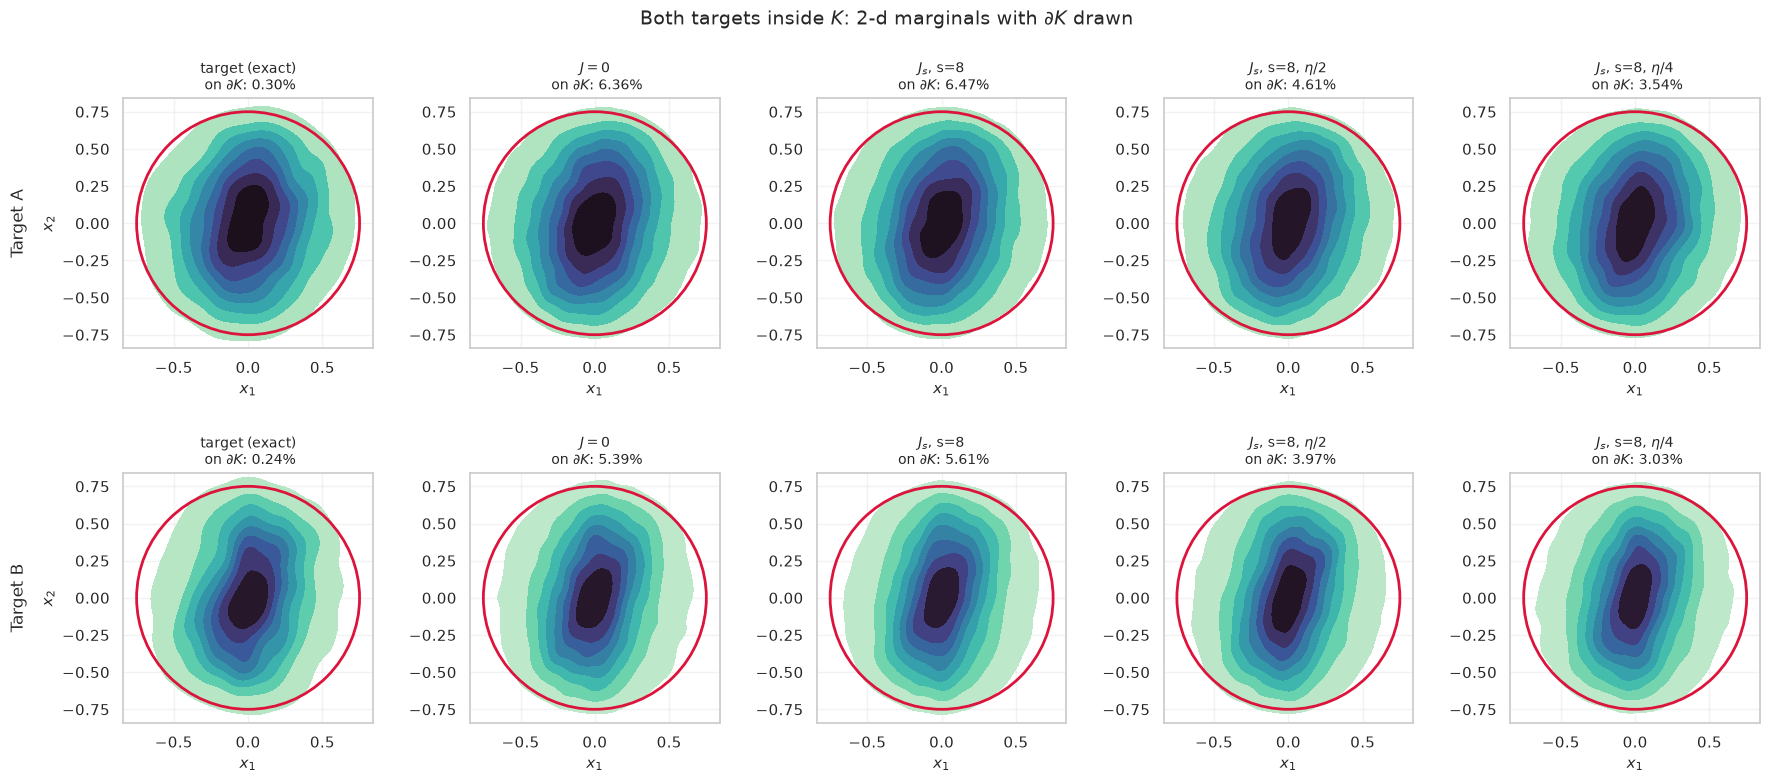

In [16]:
SHOW = ([("target (exact)", None), ("$J = 0$", "J = 0"), (TOP, TOP)]
        + [("{}, $\\eta$/{}".format(TOP, c), "{}, $\\eta$/{}".format(TOP, c))
           for c in REFINE])
fig, axes = plt.subplots(2, len(SHOW), figsize=(3.6 * len(SHOW), 7.6))
for row, kind in enumerate(TARGETS):
    for col, (name, key) in enumerate(SHOW):
        X = refs[kind] if key is None else (
            RES[kind][key]["X"] if key in RES[kind] else RES_R[kind][key]["X"]).reshape(-1, d)
        ax = axes[row, col]
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=9, ax=ax, thresh=0.02, cmap="mako_r")
        ax.add_patch(Circle((0, 0), R, edgecolor="crimson", facecolor="none", linewidth=2.0))
        ax.set_xlim(-1.12 * R, 1.12 * R); ax.set_ylim(-1.12 * R, 1.12 * R)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title("{}\n on $\\partial K$: {:.2%}".format(name, on_boundary(X)), fontsize=10)
        ax.set_xlabel("$x_1$", fontsize=11)
        ax.set_ylabel("$x_2$" if col == 0 else "", fontsize=11)
        ax.grid(alpha=0.25)
    axes[row, 0].text(-0.42, 0.5, TARGETS[kind].split(":")[0], transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="center", fontsize=12)
fig.suptitle(r"Both targets inside $K$: 2-d marginals with $\partial K$ drawn", fontsize=14, y=1.01)
plt.tight_layout()
fig.subplots_adjust(hspace=0.5)
plt.savefig("figures/cross_inK_both.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

$R=0.75$, 5000 iterations, $J=0$ against $s=4$ and $s=8$.

### The ball is filled — more so than at any radius tried

Median $\lVert x\rVert/R$ is 0.742 and 0.713, the 99th percentile 0.995 and 0.996, and the mass beyond
$0.75R$ is 0.487 and 0.434 against 0.578 for a uniform ball. Tightening $R$ from 1.5 to 1 to 0.75 moved the
outer-shell fraction 0.399 → 0.456 → 0.487 on Target A: the smaller the ball, the more completely the
target fills it, because the truncation cuts a larger share of the unconstrained mass.

The constrained target is now nearly **isotropic** — coordinate sds $(0.275,0.325,0.353)$ and
$(0.238,0.326,0.349)$, anisotropy 1.28 and 1.46, against 34.6 for the unconstrained $\Sigma$. Whatever
$J_s$ buys here is therefore bought entirely from the geometry of the constraint, with no help from
stretched directions in the target.

### Speed, with no accuracy cost at all

| | $\tau(2\times)$ | $\tau(3\times)$ | $\tau(5\times)$ | stationary $W_1$ | max KS | on $\partial K$ |
|---|---|---|---|---|---|---|
| **A** $J=0$ | 803 [781, 834] | 703 [684, 716] | 572 [562, 581] | 0.0101 [0.0091, 0.0111] | 0.0235 | 6.36% |
| **A** $s=4$ | 700 (1.15×) | 609 (1.15×) | 488 (1.17×) | 0.0101 [0.0091, 0.0111] | 0.0235 | 6.40% |
| **A** $s=8$ | **534 (1.50×)** | **472 (1.49×)** | **375 (1.52×)** | 0.0099 [0.0088, 0.0109] | 0.0228 | 6.47% |
| **B** $J=0$ | 1109 [1066, 1153] | 881 [847, 919] | 709 [691, 728] | 0.0101 [0.0096, 0.0106] | 0.0257 | 5.39% |
| **B** $s=4$ | 812 (1.37×) | 694 (1.27×) | 544 (1.30×) | 0.0097 [0.0093, 0.0102] | 0.0251 | 5.44% |
| **B** $s=8$ | **591 (1.88×)** | **491 (1.80×)** | **388 (1.83×)** | 0.0101 [0.0095, 0.0105] | 0.0263 | 5.61% |

Two things are cleaner here than at any larger radius. First, **every** threshold resolves — none is marked
*too close*, because the attainable error (0.0101) now sits comfortably under $2\times$ the floor on both
targets. The speed-up is stable across all three (1.15/1.15/1.17 and 1.50/1.49/1.52 on A), which is what a
genuine rate looks like; a number that drifts with the threshold is measuring something else. Second, the
accuracy cost has vanished entirely: stationary $W_1$ and max KS are indistinguishable across $s$ on both
targets. At $R=1.5$, $s=16$ cost a factor of 1.5 in stationary error; at $R=0.75$, $s=8$ costs nothing,
because $\lVert J_s(x)\rVert_2=s\lVert x\rVert\le sR$ makes the same $s$ a gentler field on a smaller ball.

The gain is correspondingly smaller: **1.50× and 1.80×** at $s=8$, against 2.95× and 3.22× for $s=16$ at
$R=1$. That is the same trade seen from the other side — the tighter ball is what removed the accuracy
cost, and it removed part of the speed-up with it.

### The stepsize trade no longer pays, and the reason is arithmetic

| | $\eta$ | $\tau(3\times)$ | vs $J=0$ | stationary $W_1$ | on $\partial K$ |
|---|---|---|---|---|---|
| **A** $J=0$ | 5.0e-4 | 703 | — | 0.0101 | 6.36% |
| **A** $s=8$ | 5.0e-4 | 472 | 1.49× | 0.0099 | 6.47% |
| **A** $s=8$ | 2.5e-4 | 919 | **0.77×** | 0.0077 | 4.61% |
| **A** $s=8$ | 1.3e-4 | 1812 | **0.39×** | 0.0088 | 3.54% |
| **B** $J=0$ | 5.0e-4 | 881 | — | 0.0101 | 5.39% |
| **B** $s=8$ | 5.0e-4 | 491 | 1.80× | 0.0101 | 5.61% |
| **B** $s=8$ | 2.5e-4 | 975 | **0.90×** | 0.0094 | 3.97% |
| **B** $s=8$ | 1.3e-4 | 1900 | **0.46×** | 0.0090 | 3.03% |

Refining $\eta$ by $c$ costs about a factor $c$ in iterations and buys about $1/\sqrt c$ on the atom, so the
trade is profitable only while the **speed-up exceeds $c$**. At $R=1$ with $s=16$ the speed-up was 2.95×,
comfortably above $c=2$, and $\eta/2$ still beat $J=0$ on iterations. Here the speed-up is 1.49× and 1.80×,
*below* $c=2$, and the $\eta/2$ rows come out at 0.77× and 0.90× — slower than $J=0$. The atom does fall as
advertised (6.36% → 4.61% → 3.54%), and atom$/\sqrt\eta$ stays constant to within 11%, so the mechanism is
intact; there is simply no longer enough speed-up to pay for it.

Dropping $s=16$ is what closed this off. The trade is available exactly when a strength is admissible
*and* fast enough, and at this radius $s=8$ is not.

### Two caveats

* On Target A the $\eta/2$ row reads stationary $W_1$ = 0.0077 [0.0069, 0.0088], **below** the sampling
  floor estimate of 0.0092. That is not a sampler beating the floor; it means the floor itself — estimated
  from only 4 exact resamples — is uncertain at about this level, while the sampler figures average 8
  replicas over 20 tracking points. Differences of this size between a scheme and the floor should not be
  read as real.
* The boundary atom is larger at this radius (6.36% and 5.39% against target values of 0.30% and 0.24%)
  precisely because the ball is filled and mass sits against the wall. It is flat in $s$, as it must be for
  an exactly tangential field, and it is a property of projection rather than of $J_s$.